Text(0.5, 1.0, 'Aqua Elements of the Image')

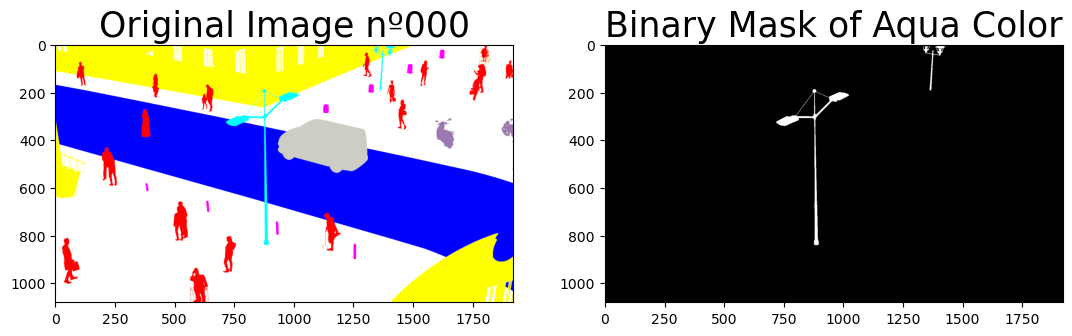

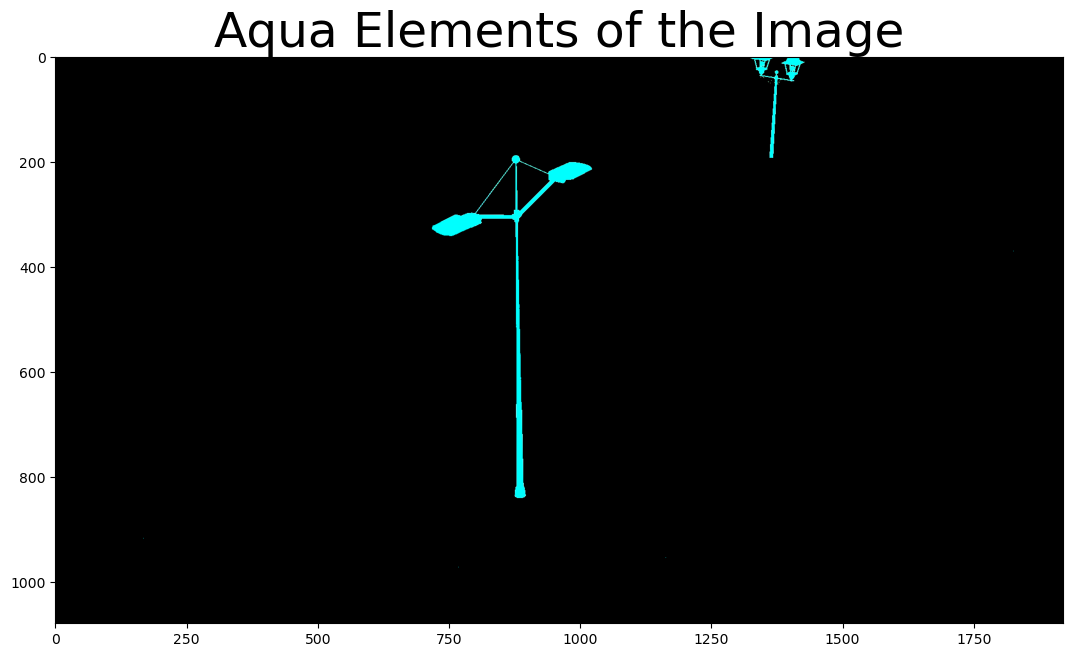

In [2]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))

from core.validation import get_valid_image_number
from dotenv import load_dotenv
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para AQUA ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Define limits for Aqua Color >> HSV (R:255, G:82, B:70) to (R:255, G:255, B:90)
lower_bound = np.array([70, 82, 255]) #[B, G, R]
upper_bound = np.array([90, 255, 255]) #[B, G, R]

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
# plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Aqua Color",fontdict={'fontsize': 25})
# plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Aqua Elements of the Image",fontdict={'fontsize':35})
# plt.axis('off')

In [ ]:
print(mask.shape)